# Machine Learning Data Cleaning

### Step 1: Importing important libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Reading the dataset

In [3]:
df = pd.read_csv("tested.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
161,1053,0,3,"Touma, Master. Georges Youssef",male,7.0,1,1,2650,15.2458,NaN,C
343,1235,1,1,"Cardeza, Mrs. James Warburton Martinez (Charlo...",female,58.0,0,1,PC 17755,512.3292,B51 B53 B55,C
339,1231,0,3,"Betros, Master. Seman",male,NaN,0,0,2622,7.2292,NaN,C
408,1300,1,3,"Riordan, Miss. Johanna Hannah""""",female,NaN,0,0,334915,7.7208,NaN,Q
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
46,938,0,1,"Chevre, Mr. Paul Romaine",male,45.0,0,0,PC 17594,29.7000,A9,C
336,1228,0,2,"de Brito, Mr. Jose Joaquim",male,32.0,0,0,244360,13.0000,NaN,S
348,1240,0,2,"Giles, Mr. Ralph",male,24.0,0,0,248726,13.5000,NaN,S
78,970,0,2,"Aldworth, Mr. Charles Augustus",male,30.0,0,0,248744,13.0000,NaN,S
378,1270,0,1,"Hipkins, Mr. William Edward",male,55.0,0,0,680,50.0000,C39,S


### Step 3: Studying the dataset

In [6]:
df.shape

(418, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [8]:
print(df.isnull().sum())
print()
print("="*24)
print("here Income col has some null values.")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

here Income col has some null values.


In [9]:
print(df.duplicated().sum())
print("No duplicated row")

0
No duplicated row


In [10]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [11]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
34,926,0,1,"Mock, Mr. Philipp Edmund",male,30.0,1,0,13236,57.75,C78,C
391,1283,1,1,"Lines, Mrs. Ernest H (Elizabeth Lindsey James)",female,51.0,0,1,PC 17592,39.40,D28,S
368,1260,1,1,"Gibson, Mrs. Leonard (Pauline C Boeson)",female,45.0,0,1,112378,59.40,NaN,C
57,949,0,3,"Abelseth, Mr. Olaus Jorgensen",male,25.0,0,0,348122,7.65,F G63,S
41,933,0,1,"Franklin, Mr. Thomas Parham",male,NaN,0,0,113778,26.55,D34,S


### Step 4: Performing EDA on the dataset using Univariate Analysis

#### A. Categorical Data

##### Countplot

In [12]:
import seaborn as sns

Survived
0    266
1    152
Name: count, dtype: int64

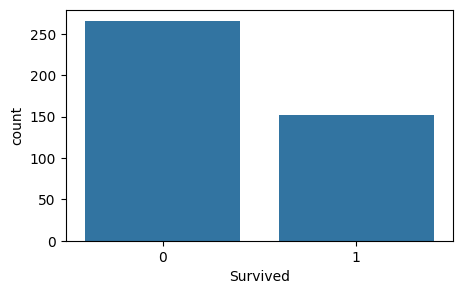

In [13]:
plt.figure(figsize=(5,3))
sns.countplot(x=df['Survived'])
df['Survived'].value_counts()

Pclass
3    218
1    107
2     93
Name: count, dtype: int64

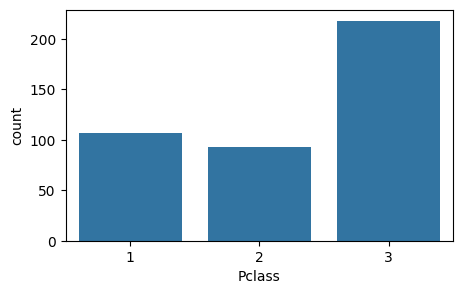

In [14]:
plt.figure(figsize=(5,3))
sns.countplot(x=df['Pclass'])
df['Pclass'].value_counts()

In [15]:
df.groupby('Pclass')['Fare'].mean()

Pclass
1    94.280297
2    22.202104
3    12.459678
Name: Fare, dtype: float64

Sex
male      266
female    152
Name: count, dtype: int64

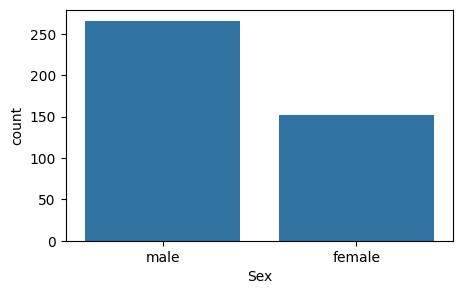

In [16]:
plt.figure(figsize=(5,3))
sns.countplot(x=df['Sex'])
df['Sex'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

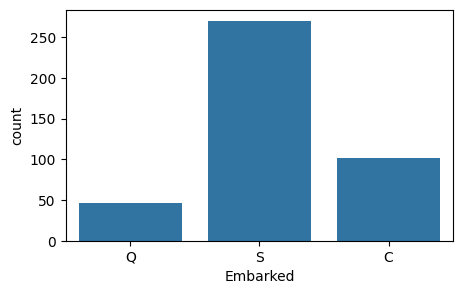

In [17]:
plt.figure(figsize=(5,3))
sns.countplot(x=df['Embarked'])
df['Embarked'].value_counts()

##### Piechart

<Axes: ylabel='count'>

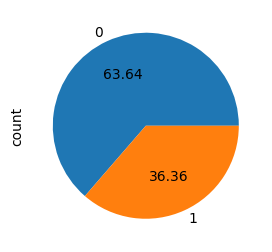

In [18]:
plt.figure(figsize=(3,5))
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

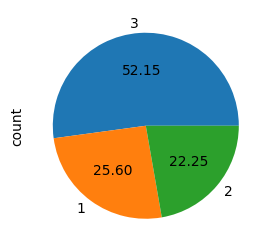

In [19]:
plt.figure(figsize=(3,5))
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

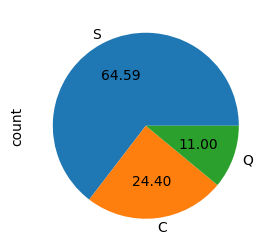

In [20]:
plt.figure(figsize=(3,5))
df['Embarked'].value_counts().plot(kind='pie',autopct='%.2f')

#### B. Numerical Data

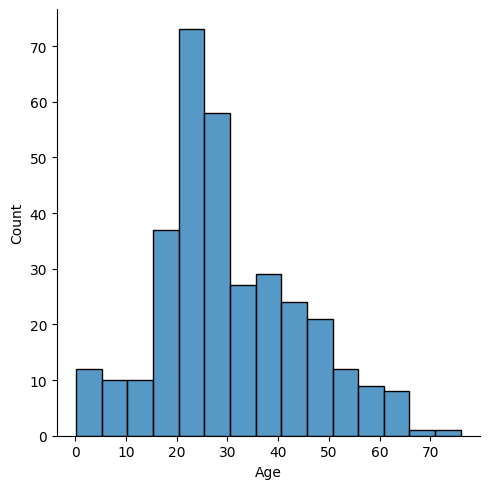

In [39]:
sns.displot(df['Age'])

<Axes: xlabel='Age'>

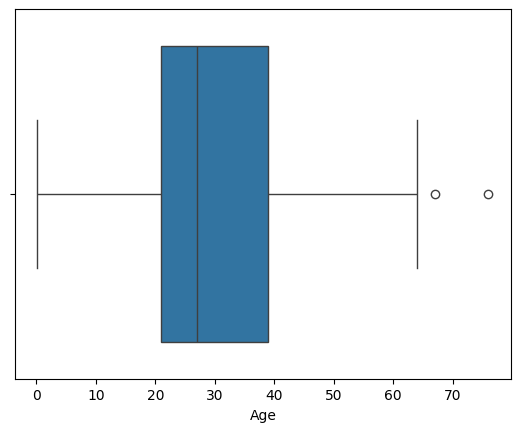

In [31]:
sns.boxplot(x=df['Age'])

In [34]:
print(df['Age'].min())

0.17


In [33]:
print(df['Age'].max())

76.0


In [35]:
print(df['Age'].mean())

30.272590361445783


In [37]:
print(df['Age'].skew())

0.4573612871503845
